# **DEN - 02) Crypctocurrency Analysis**

## **1) Prepare for execution**

Load used libraries

In [192]:
# General purpose
import os
import pandas as pd

# Data viz
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# API for stock prices
from pycoingecko import CoinGeckoAPI

# Plot candlesticks
import mplfinance as mpf

## **2)Download data via CoinGecko API**

Downoad crypto prices using the Coin Gecko API. The data is fetched for the last 365, this is the limiatation of the free version.

In [94]:
# Generate client object
client_coin = CoinGeckoAPI()

# Define currencies to be downloaded and df to store historic prices
coin_ids = ["bitcoin", "ethereum", "ripple", "binancecoin", "solana", "dogecoin"]
df_data = pd.DataFrame()

# Iterate over every selecter currency
for coin_id in coin_ids:

    # Download and make data digestible
    coin_data = client_coin.get_coin_market_chart_by_id(id=coin_id, vs_currency="usd", days=365)
    df_temporal = pd.DataFrame(coin_data["prices"])
    df_temporal.rename({0:"date", 1:"price"}, axis=1, inplace=True)
    df_temporal["date"] = pd.to_datetime(df_temporal["date"], unit="ms")
    df_temporal.set_index(["date"], inplace=True)

    # Store data in an unified df
    df_data[coin_id] = df_temporal["price"]

## **3) Visualize data**

Data is normalized using the price in the begining of the period of analysis. The different cryptos are compared.

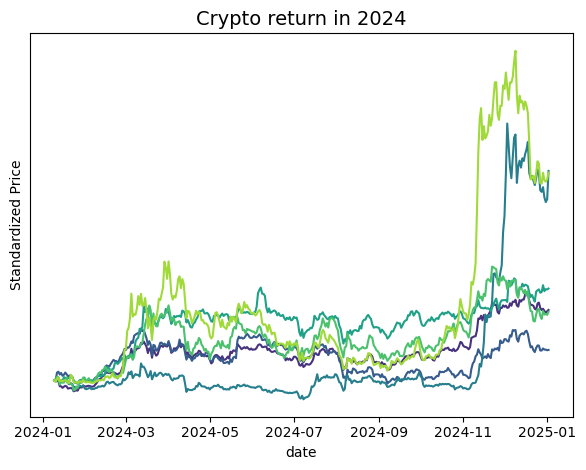

In [123]:
# Create temporal df to manipulate raw data
df_temporal = df_results.copy()
df_temporal.dropna(inplace=True, how="any")

# Standardize data by the price in the start date
df_temporal = df_temporal / df_temporal.iloc[0,:]
df_temporal = df_temporal.melt(ignore_index=False, var_name="currency", value_name="price")

# Generate visualization of standardized prices
plt.figure(figsize=(6,4.8))
sns.lineplot(x=df_temporal.index, y="price", data=df_temporal, hue="currency", palette="viridis", legend=False)
plt.title("Crypto return in 2024", fontsize=14)
plt.yticks([]), plt.ylabel("Standardized Price")
plt.tight_layout()
plt.show()

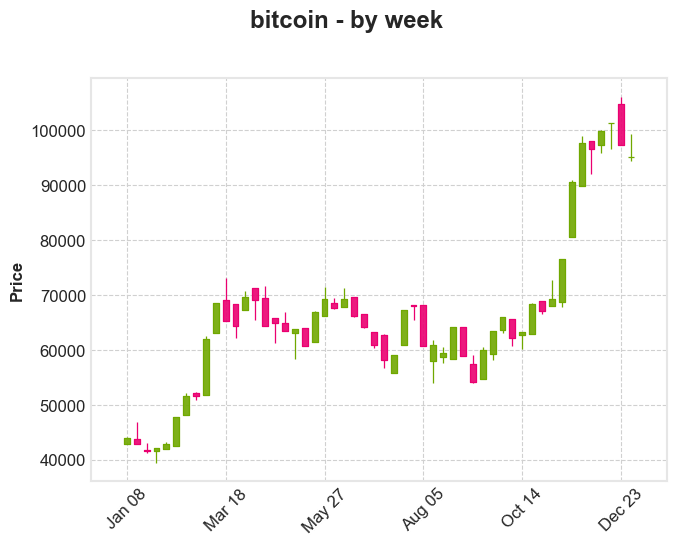

In [197]:
# Define currency to creat candles graph
currency = "bitcoin"

# Extract and format data for selected currency
df_temporal = df_data[df_data.index.year < 2025]
df_temporal = df_temporal[[currency]]
df_temporal.drop(["2024-12-30", "2024-12-31"], axis=0, inplace=True)
df_temporal = df_temporal.groupby(df_temporal.index.isocalendar().week)

# Create df that's passed to the candle graph function
df_candles = pd.DataFrame(index=df_temporal.mean().index, columns=["Open", "High", "Low", "Close", "Volume"])
df_candles["Open"] = df_temporal.first()
df_candles["High"] = df_temporal.max()
df_candles["Low"] = df_temporal.min()
df_candles["Close"] = df_temporal.last()
df_candles["Volume"] = 1
df_candles.index = pd.to_datetime([f"2024-W{week:02d}-1" for week in df_candles.index], format="%Y-W%U-%w")

# Create candle stick graph
mpf.plot(df_candles, type="candle", style="binance", title=currency+" - by week")

## **4) Save data locally and create Tableau viz**

The data is saved in a csv file. Externally, a Tableau viz is created and displayed in this NB.

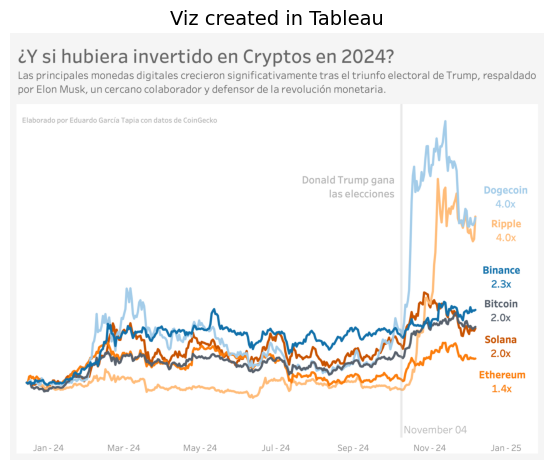

In [126]:
# Get folder to save and read data locally
main_folder = os.path.dirname(os.path.dirname(os.getcwd()))
main_folder += "/PUEE/Ejercicios/Cryptos"

# Save df with normalized prices
df_temporal.to_csv(main_folder + "/crypto.csv")

# Load Tableau-generated image
image_path = main_folder + "/crypto.png"
image = mpimg.imread(image_path)

# Display the image
plt.figure(figsize=(6,4.8))
plt.imshow(image)
plt.axis('off')  # Turn off axes for better display
plt.title("Viz created in Tableau", fontsize=14)
plt.tight_layout()
plt.show()